In [2]:
import pandas as pd
import os
from linearmodels.panel import PanelOLS

In [3]:
# --- Load dataset ---
output_dir = "/Users/ckatchmart/sipecon01/cleaned data"
file_path = os.path.join(output_dir, "fte_by_school_cleaned.csv")
df = pd.read_csv(file_path)
# --- Keep only required columns and drop missing values ---
df = df[['scode', 'year', 'utot_sus', 'fte100']].dropna()
# --- Set panel structure with MultiIndex (scode = unit, year = time) ---
df = df.set_index(['scode', 'year'])
# --- Run fixed effects regression with entity and time effects ---
model = PanelOLS.from_formula('fte100 ~ utot_sus + EntityEffects + TimeEffects', data=df)
results = model.fit()
# --- Display regression output ---
print(results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 fte100   R-squared:                        0.0052
Estimator:                   PanelOLS   R-squared (Between):              0.0349
No. Observations:               68896   R-squared (Within):               0.0055
Date:                Fri, Jul 11 2025   R-squared (Overall):              0.0345
Time:                        11:41:18   Log-likelihood                 -2.03e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      305.22
Entities:                       10641   P-value                           0.0000
Avg Obs:                       6.4746   Distribution:                 F(1,58248)
Min Obs:                       1.0000                                           
Max Obs:                       7.0000   F-statistic (robust):             305.22
                            

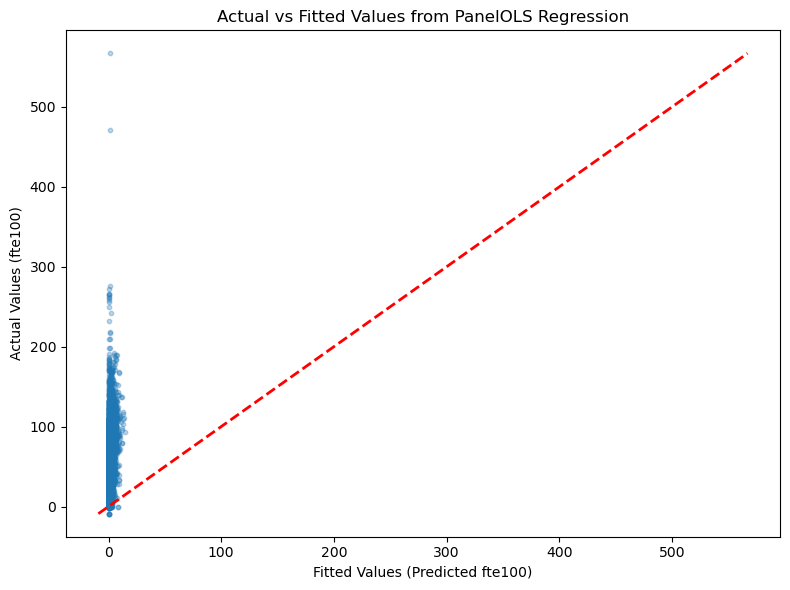

In [4]:
import numpy as np

import matplotlib.pyplot as plt

# Get the fitted values and actual values
fitted = results.fitted_values
actual = df['fte100']

# Scatter plot of actual vs fitted values
plt.figure(figsize=(8, 6))
plt.scatter(fitted, actual, alpha=0.3, s=10)
plt.xlabel('Fitted Values (Predicted fte100)')
plt.ylabel('Actual Values (fte100)')
plt.title('Actual vs Fitted Values from PanelOLS Regression')
plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', lw=2)
plt.tight_layout()
plt.show()